### Subargument 4: Higher academic performance may go alongside higher stress 

_Despite may affect mental wellbeing, strictly follow intense study schedule brings fruitful result_

In [1]:
# Import
import pandas as pd
import numpy as np
import plotly.graph_objs as go
import plotly.express as px

from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [7]:
# Read in
df = pd.read_csv("student_lifestyle_dataset.csv")

# Remove duplicates


df = df.drop_duplicates()


# Handle missing values


    # Fill numerical missing values with median
numeric_cols = df.select_dtypes(include=np.number).columns
    
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

    # Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns
    
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# Filter unwanted outliers
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)


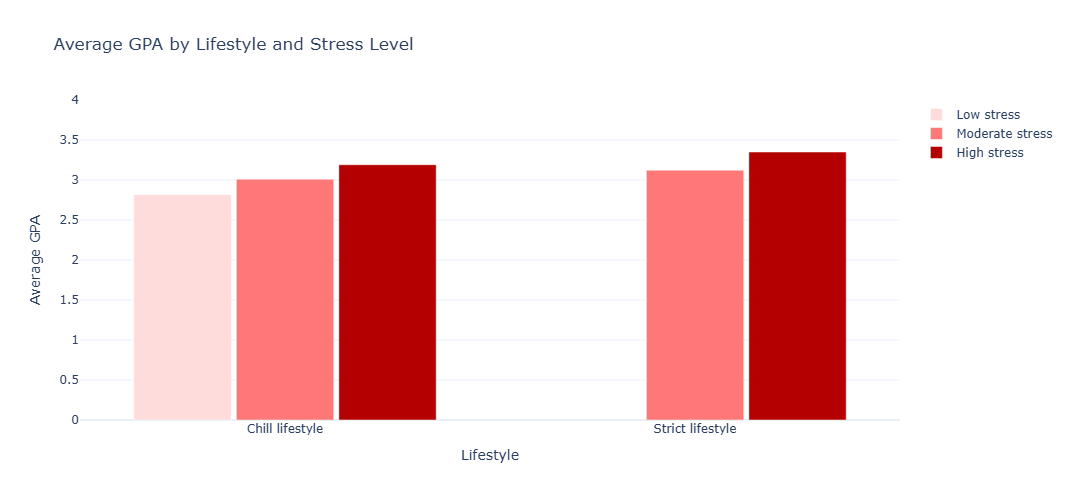

In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Create lifestyle variable
df["Lifestyle"] = np.where(
    (df["Study_Hours_Per_Day"] >= 7.5) &
    (df["Social_Hours_Per_Day"] <= 2.5),
    "Strict lifestyle",
    "Chill lifestyle"
)

# Calculate average GPA by lifestyle and stress level
plot_df = (
    df.groupby(["Lifestyle", "Stress_Level"])["GPA"]
      .mean()
      .unstack()
      .reset_index()
)

# Ensure consistent ordering
stress_order = ["Low", "Moderate", "High"]
plot_df = plot_df[["Lifestyle"] + stress_order]

# Create grouped bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=plot_df["Lifestyle"],
    y=plot_df["Low"],
    name="Low stress",
    marker_color="rgb(255,220,220)"  # light red
))

fig.add_trace(go.Bar(
    x=plot_df["Lifestyle"],
    y=plot_df["Moderate"],
    name="Moderate stress",
    marker_color="rgb(255,120,120)"  # medium red
))

fig.add_trace(go.Bar(
    x=plot_df["Lifestyle"],
    y=plot_df["High"],
    name="High stress",
    marker_color="rgb(180,0,0)"      # dark red
))

fig.update_layout(
    title="Average GPA by Lifestyle and Stress Level",
    xaxis_title="Lifestyle",
    yaxis_title="Average GPA",
    yaxis=dict(
        range=[0, 4]
    ),
    barmode="group",
    bargap=0.25,
    bargroupgap=0.05,
    height=500,
    template="plotly_white"
)

fig.show()

#### Interpretation

- Strictly living students experience moderate to high stress, but also achieve higher GPA, specifically a 0.2 gap for high stress and 0.1 gap for moderate
- Because GPA has the maximum of 4 and is the average of 100+ ECTs, a difference of 0.1 is already notable 


#### Design justification

The clustered columns chart is chosen to illustrate data for the argument because there are 2 main variables: average GPA (ratio)and stress level (categorical), which is grouped into 2 groups of “Strict” and “Chill”. This type of chart helps show the correlation of grade and stress for each group. Additionally, aligning the 2 groups side-by-side assist comparison. Different shades of red are used to represent stress levels, bringing the necessary contrast for readers to easily notice levels of stress: the more intense the red shade, the higher the stress level. 